In [1]:
import polars as pl
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split

# Paths
PARQUET_PATH = r"D:\FYP\SafeRoute-AI\data\us_accidents_clean.parquet"
MODELS_DIR = r"D:\FYP\SafeRoute-AI\models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Loading preprocessed clean parquet... ⏳")
df = pl.read_parquet(PARQUET_PATH)
print(f"✅ Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")

# Drop geographic coordinates from direct ML features (lat/long are reserved for Tier 2 DBSCAN clustering)
# Keep only predictive environmental, temporal, road infrastructure, and spatial-encoded features
features_to_exclude = ["Severity", "Start_Lat", "Start_Lng"]
feature_cols = [c for c in df.columns if c not in features_to_exclude]

print(f"\nTarget column: Severity")
print(f"Total features for prediction: {len(feature_cols)}")
print("Features:", feature_cols[:10], "... [and more]")

Loading preprocessed clean parquet... ⏳
✅ Loaded 7,606,833 rows × 40 columns

Target column: Severity
Total features for prediction: 37
Features: ['Source', 'Distance(mi)', 'City', 'County', 'State', 'Timezone', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)'] ... [and more]


In [2]:
# Convert Polars DataFrame to Pandas for Scikit-Learn / SMOTE compatibility
# We draw a balanced stratified sample of 500,000 records for fast & robust ensemble training
SAMPLE_SIZE = 500_000

print(f"Sampling {SAMPLE_SIZE:,} records with stratification on Severity...")

# Extract X (features) and y (target)
X_all = df.select(feature_cols).to_pandas()
y_all = df.select("Severity").to_pandas()["Severity"]

# XGBoost/LightGBM require 0-indexed classes (0, 1, 2, 3 instead of 1, 2, 3, 4)
y_all = y_all - 1  # 0: Severity 1 (Minor), 1: Severity 2, 2: Severity 3, 3: Severity 4 (Fatal)

# Perform stratified sampling
_, X_sample, _, y_sample = train_test_split(
    X_all, y_all, 
    test_size=SAMPLE_SIZE, 
    stratify=y_all, 
    random_state=42
)

# Perform 80% Train / 20% Test Split on the sample
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.20,
    stratify=y_sample,
    random_state=42
)

print(f"\n✅ Data split complete!")
print(f"   Training Set : {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"   Testing Set  : {X_test.shape[0]:,} samples × {X_test.shape[1]} features")

print("\nTraining Set Class Distribution (0=Minor, 3=Fatal):")
for label, count in y_train.value_counts().sort_index().items():
    pct = (count / len(y_train)) * 100
    print(f"   Class {label} (Severity {label+1}): {count:>7,} ({pct:5.2f}%)")

Sampling 500,000 records with stratification on Severity...

✅ Data split complete!
   Training Set : 400,000 samples × 37 features
   Testing Set  : 100,000 samples × 37 features

Training Set Class Distribution (0=Minor, 3=Fatal):
   Class 0 (Severity 1):   3,440 ( 0.86%)
   Class 1 (Severity 2): 317,976 (79.49%)
   Class 2 (Severity 3):  68,022 (17.01%)
   Class 3 (Severity 4):  10,562 ( 2.64%)


In [5]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Class counts before SMOTE:", Counter(y_train))

# Configure SMOTE sampling strategy:
# Boost Class 0 (Severity 1) from 3,440 to 30,000
# Boost Class 3 (Severity 4) from 10,562 to 50,000
# Leave majority Class 1 and 2 as-is for stability
smote_strategy = {
    0: 30_000,
    1: y_train.value_counts()[1],  # 317,976
    2: y_train.value_counts()[2],  # 68,022
    3: 50_000
}

print("\nApplying SMOTE oversampling on training data... ⏳")
smote = SMOTE(sampling_strategy=smote_strategy, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\n✅ SMOTE completed successfully!")
print(f"   Original Train Shape : {X_train.shape[0]:,} samples")
print(f"   Resampled Train Shape: {X_train_res.shape[0]:,} samples")

print("\nResampled Training Set Class Distribution:")
for label, count in y_train_res.value_counts().sort_index().items():
    pct = (count / len(y_train_res)) * 100
    print(f"   Class {label} (Severity {label+1}): {count:>7,} ({pct:5.2f}%)")

Class counts before SMOTE: Counter({1: 317976, 2: 68022, 3: 10562, 0: 3440})

Applying SMOTE oversampling on training data... ⏳

✅ SMOTE completed successfully!
   Original Train Shape : 400,000 samples
   Resampled Train Shape: 465,998 samples

Resampled Training Set Class Distribution:
   Class 0 (Severity 1):  30,000 ( 6.44%)
   Class 1 (Severity 2): 317,976 (68.24%)
   Class 2 (Severity 3):  68,022 (14.60%)
   Class 3 (Severity 4):  50,000 (10.73%)


In [6]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("Training Random Forest Classifier on resampled training set (465,998 samples)... ⏳")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=16,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train_res, y_train_res)
rf_duration = time.time() - start_time
print(f"✅ Random Forest Training Completed in {rf_duration:.2f} seconds!")

# Save the trained model
rf_path = os.path.join(MODELS_DIR, "rf_model.joblib")
joblib.dump(rf_model, rf_path)
print(f"Saved model to: {rf_path}")

# Evaluate on pristine test set (100,000 samples)
print("\nEvaluating Random Forest on Test Set...")
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Macro F1-Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=["Severity 1", "Severity 2", "Severity 3", "Severity 4"]))

Training Random Forest Classifier on resampled training set (465,998 samples)... ⏳


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   28.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


✅ Random Forest Training Completed in 28.23 seconds!
Saved model to: D:\FYP\SafeRoute-AI\models\rf_model.joblib

Evaluating Random Forest on Test Set...


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.2s finished


Random Forest Test Accuracy: 0.8295
Random Forest Macro F1-Score: 0.5531

Classification Report (Random Forest):
              precision    recall  f1-score   support

  Severity 1       0.40      0.77      0.53       860
  Severity 2       0.86      0.96      0.90     79494
  Severity 3       0.70      0.33      0.45     17005
  Severity 4       0.40      0.28      0.33      2641

    accuracy                           0.83    100000
   macro avg       0.59      0.58      0.55    100000
weighted avg       0.81      0.83      0.81    100000



In [7]:
import xgboost as xgb

print("Training XGBoost Classifier on resampled training set (465,998 samples)... ⏳")
start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",      # fast histogram optimization
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_res, y_train_res)
xgb_duration = time.time() - start_time
print(f"✅ XGBoost Training Completed in {xgb_duration:.2f} seconds!")

# Save the trained model
xgb_path = os.path.join(MODELS_DIR, "xgb_model.joblib")
joblib.dump(xgb_model, xgb_path)
print(f"Saved model to: {xgb_path}")

# Evaluate on test set
print("\nEvaluating XGBoost on Test Set...")
y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost Macro F1-Score: {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=["Severity 1", "Severity 2", "Severity 3", "Severity 4"]))

Training XGBoost Classifier on resampled training set (465,998 samples)... ⏳
✅ XGBoost Training Completed in 18.25 seconds!
Saved model to: D:\FYP\SafeRoute-AI\models\xgb_model.joblib

Evaluating XGBoost on Test Set...
XGBoost Test Accuracy: 0.8584
XGBoost Macro F1-Score: 0.6119

Classification Report (XGBoost):
              precision    recall  f1-score   support

  Severity 1       0.50      0.66      0.57       860
  Severity 2       0.89      0.94      0.92     79494
  Severity 3       0.71      0.56      0.63     17005
  Severity 4       0.48      0.25      0.33      2641

    accuracy                           0.86    100000
   macro avg       0.65      0.60      0.61    100000
weighted avg       0.85      0.86      0.85    100000



In [8]:
import lightgbm as lgb

print("Training LightGBM Classifier on resampled training set (465,998 samples)... ⏳")
start_time = time.time()

lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multiclass",
    num_class=4,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train_res, y_train_res)
lgbm_duration = time.time() - start_time
print(f"✅ LightGBM Training Completed in {lgbm_duration:.2f} seconds!")

# Save the trained model
lgbm_path = os.path.join(MODELS_DIR, "lgbm_model.joblib")
joblib.dump(lgbm_model, lgbm_path)
print(f"Saved model to: {lgbm_path}")

# Evaluate on test set
print("\nEvaluating LightGBM on Test Set...")
y_pred_lgbm = lgbm_model.predict(X_test)

print(f"LightGBM Test Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"LightGBM Macro F1-Score: {f1_score(y_test, y_pred_lgbm, average='macro'):.4f}")
print("\nClassification Report (LightGBM):")
print(classification_report(y_test, y_pred_lgbm, target_names=["Severity 1", "Severity 2", "Severity 3", "Severity 4"]))

Training LightGBM Classifier on resampled training set (465,998 samples)... ⏳
✅ LightGBM Training Completed in 11.42 seconds!
Saved model to: D:\FYP\SafeRoute-AI\models\lgbm_model.joblib

Evaluating LightGBM on Test Set...
LightGBM Test Accuracy: 0.8631
LightGBM Macro F1-Score: 0.6246

Classification Report (LightGBM):
              precision    recall  f1-score   support

  Severity 1       0.59      0.63      0.61       860
  Severity 2       0.90      0.95      0.92     79494
  Severity 3       0.72      0.58      0.64     17005
  Severity 4       0.52      0.24      0.33      2641

    accuracy                           0.86    100000
   macro avg       0.68      0.60      0.62    100000
weighted avg       0.85      0.86      0.85    100000



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.3s finished


📊 Comprehensive Model Benchmark Table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC (OVR),Train Time (s)
0,Random Forest,0.82953,0.590482,0.584220,0.553068,0.808193,0.921478,28.23
1,XGBoost,0.85840,0.647095,0.604852,0.611912,0.850001,0.937189,18.25
2,LightGBM (Best),0.86309,0.681533,0.598563,0.624584,0.854572,0.941163,11.42


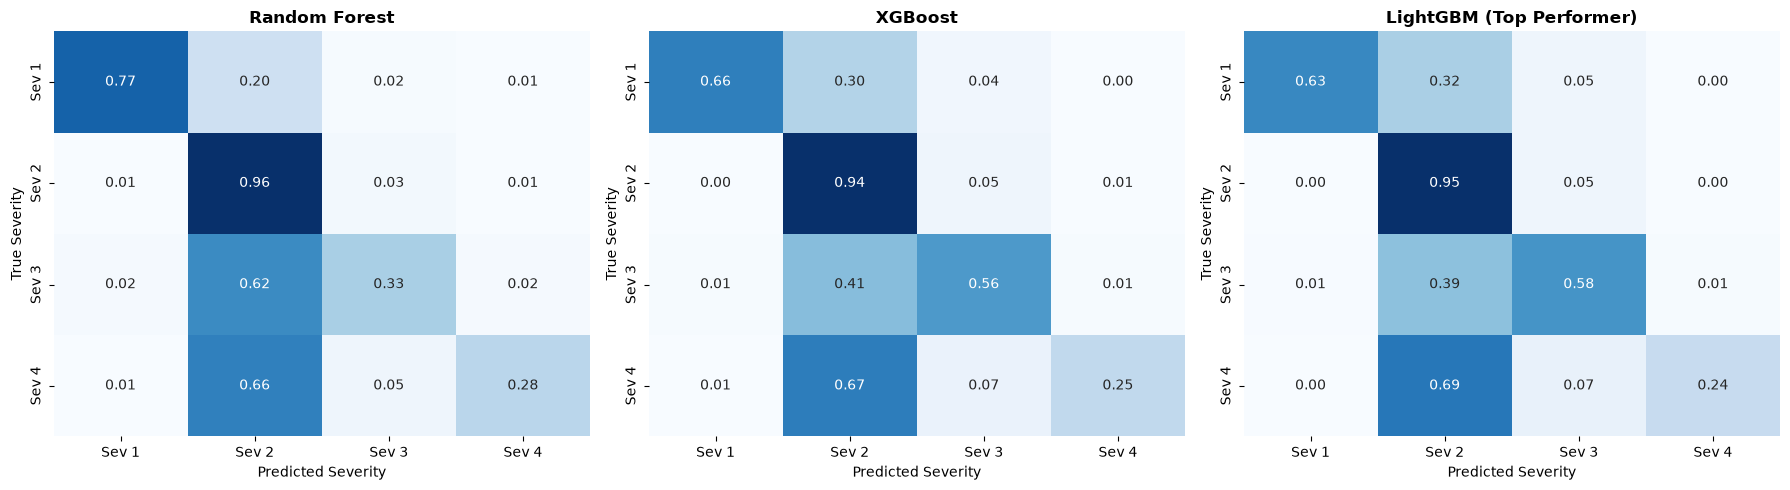

✅ Confusion Matrices saved to: D:\FYP\SafeRoute-AI\reports\10_model_confusion_matrices.png


In [9]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

REPORTS_DIR = r"D:\FYP\SafeRoute-AI\reports"

# 1. Compute multi-class ROC-AUC (One-vs-Rest)
y_prob_rf = rf_model.predict_proba(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)

auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class="ovr", average="macro")
auc_xgb = roc_auc_score(y_test, y_prob_xgb, multi_class="ovr", average="macro")
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm, multi_class="ovr", average="macro")

# 2. Build Paper-Ready Comparison DataFrame
models_summary = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Macro Precision": precision_recall_fscore_support(y_test, y_pred_rf, average="macro")[0],
        "Macro Recall": precision_recall_fscore_support(y_test, y_pred_rf, average="macro")[1],
        "Macro F1": f1_score(y_test, y_pred_rf, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred_rf, average="weighted"),
        "ROC-AUC (OVR)": auc_rf,
        "Train Time (s)": round(rf_duration, 2)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Macro Precision": precision_recall_fscore_support(y_test, y_pred_xgb, average="macro")[0],
        "Macro Recall": precision_recall_fscore_support(y_test, y_pred_xgb, average="macro")[1],
        "Macro F1": f1_score(y_test, y_pred_xgb, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred_xgb, average="weighted"),
        "ROC-AUC (OVR)": auc_xgb,
        "Train Time (s)": round(xgb_duration, 2)
    },
    {
        "Model": "LightGBM (Best)",
        "Accuracy": accuracy_score(y_test, y_pred_lgbm),
        "Macro Precision": precision_recall_fscore_support(y_test, y_pred_lgbm, average="macro")[0],
        "Macro Recall": precision_recall_fscore_support(y_test, y_pred_lgbm, average="macro")[1],
        "Macro F1": f1_score(y_test, y_pred_lgbm, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred_lgbm, average="weighted"),
        "ROC-AUC (OVR)": auc_lgbm,
        "Train Time (s)": round(lgbm_duration, 2)
    }
])

print("📊 Comprehensive Model Benchmark Table:")
display(models_summary)

# 3. Plot 3 Side-by-Side Normalized Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Sev 1", "Sev 2", "Sev 3", "Sev 4"]

for ax, preds, title in zip(
    axes, 
    [y_pred_rf, y_pred_xgb, y_pred_lgbm], 
    ["Random Forest", "XGBoost", "LightGBM (Top Performer)"]
):
    cm = confusion_matrix(y_test, preds, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Severity")
    ax.set_ylabel("True Severity")

plt.tight_layout()
cm_path = os.path.join(REPORTS_DIR, "10_model_confusion_matrices.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"✅ Confusion Matrices saved to: {cm_path}")

d:\FYP\SafeRoute-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing TreeSHAP values for LightGBM model... ⏳
✅ SHAP values computed successfully!


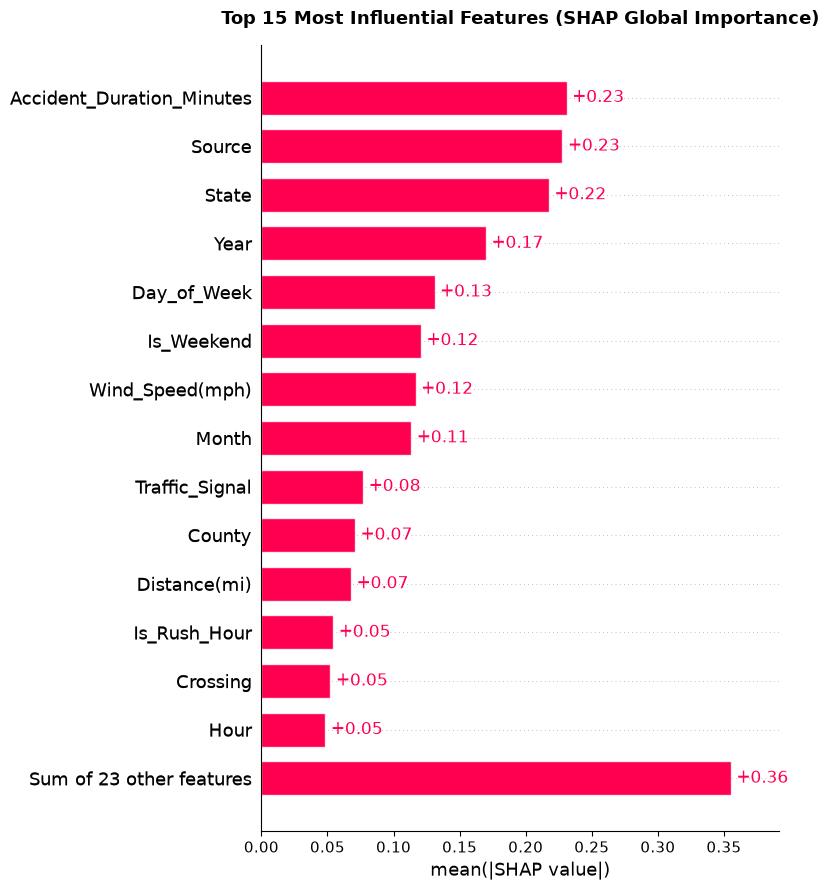

✅ Saved feature importance chart: D:\FYP\SafeRoute-AI\reports\11_shap_feature_importance.png


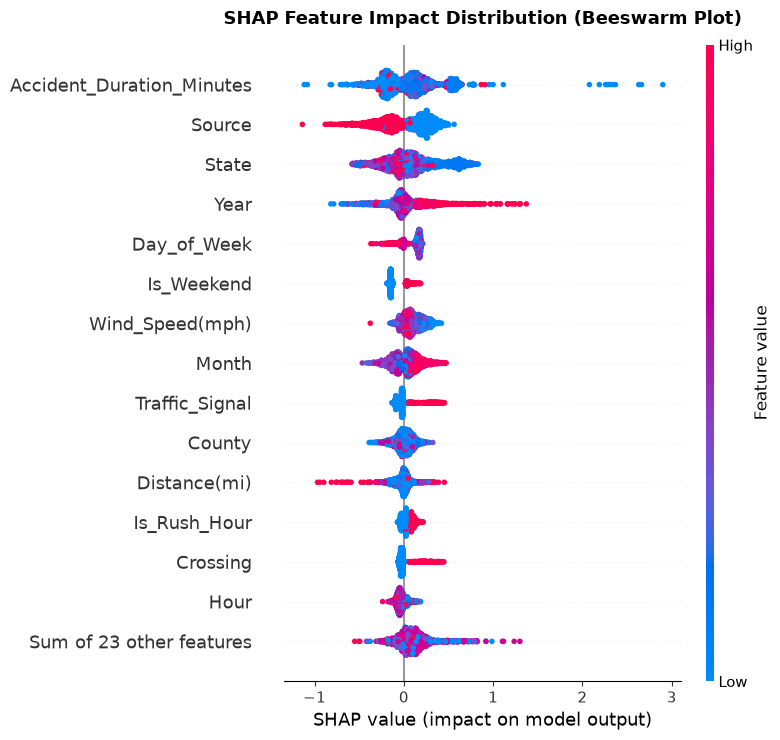

✅ Saved beeswarm summary plot: D:\FYP\SafeRoute-AI\reports\12_shap_summary_beeswarm.png


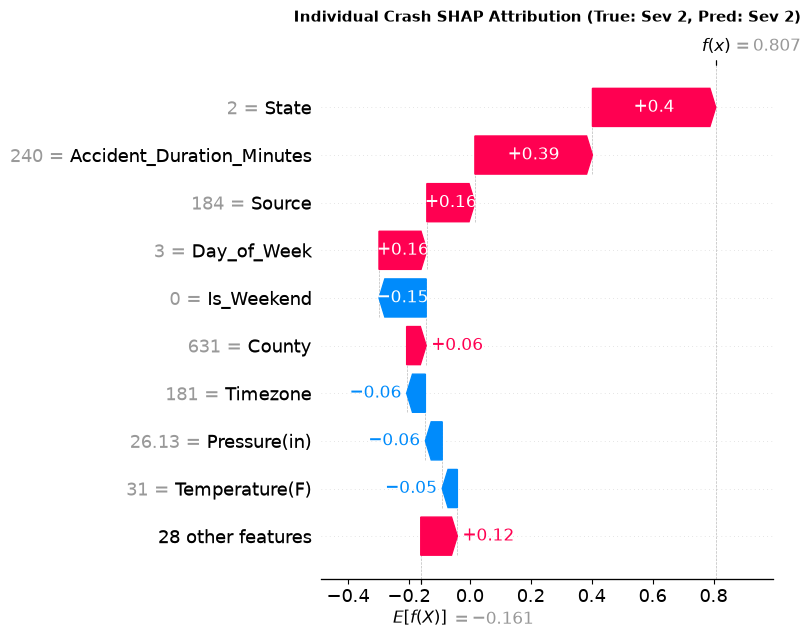

✅ Saved single crash waterfall plot: D:\FYP\SafeRoute-AI\reports\13_shap_waterfall_single_crash.png


In [10]:
import shap

print("Computing TreeSHAP values for LightGBM model... ⏳")
# Use a representative test sample of 2,000 instances for fast SHAP computation
X_shap_sample = X_test.iloc[:2000]

# Initialize TreeExplainer
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_shap_sample)

print("✅ SHAP values computed successfully!")

# 1. Global Feature Importance Bar Plot
fig, ax = plt.subplots(figsize=(10, 8))
plt.title("Top 15 Most Influential Features (SHAP Global Importance)", fontsize=13, fontweight="bold", pad=15)
shap.plots.bar(shap_values[:, :, 1], max_display=15, show=False)  # Class 1 (Severity 2 / Moderate)
plt.tight_layout()
shap_bar_path = os.path.join(REPORTS_DIR, "11_shap_feature_importance.png")
plt.savefig(shap_bar_path, dpi=150)
plt.show()
print(f"✅ Saved feature importance chart: {shap_bar_path}")

# 2. SHAP Beeswarm Summary Plot
fig, ax = plt.subplots(figsize=(10, 8))
plt.title("SHAP Feature Impact Distribution (Beeswarm Plot)", fontsize=13, fontweight="bold", pad=15)
shap.plots.beeswarm(shap_values[:, :, 1], max_display=15, show=False)
plt.tight_layout()
shap_beeswarm_path = os.path.join(REPORTS_DIR, "12_shap_summary_beeswarm.png")
plt.savefig(shap_beeswarm_path, dpi=150)
plt.show()
print(f"✅ Saved beeswarm summary plot: {shap_beeswarm_path}")

# 3. Individual Crash Prediction Explanation (Waterfall Plot)
fig, ax = plt.subplots(figsize=(9, 6))
sample_idx = 0
true_sev = y_test.iloc[sample_idx] + 1
pred_sev = y_pred_lgbm[sample_idx] + 1
plt.title(f"Individual Crash SHAP Attribution (True: Sev {true_sev}, Pred: Sev {pred_sev})", fontsize=11, fontweight="bold", pad=12)
shap.plots.waterfall(shap_values[sample_idx, :, 1], max_display=10, show=False)
plt.tight_layout()
shap_waterfall_path = os.path.join(REPORTS_DIR, "13_shap_waterfall_single_crash.png")
plt.savefig(shap_waterfall_path, dpi=150)
plt.show()
print(f"✅ Saved single crash waterfall plot: {shap_waterfall_path}")